# লিনিয়ার ক্লাসিফিকেশন**গল্প: সরলরেখা দিয়ে দুটি গ্রুপ আলাদা করা**কল্পনা করো তুমি একটি মাঠে দাঁড়িয়ে আছ যেখানে লাল আর নীল বল ছড়ানো আছে। তুমি একটি সরলরেখা এঁকে বলতে পারো: 'এই রেখার এক পাশে লাল, আরেক পাশে নীল!'লিনিয়ার ক্লাসিফিকেশন ঠিক এটাই করে - এটি একটি সরলরেখা (বা সমতল) খুঁজে বের করে যা দুটি ক্লাসকে আলাদা করে।

## আমরা কী শিখব?1. LogisticRegression2. LinearSVC3. C প্যারামিটার (নিয়মিতকরণ)4. Decision Boundary দেখা5. make_blobs দিয়ে ডেটা তৈরি

## প্রথমে লাইব্রেরি ইম্পোর্ট করি

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.datasets import make_blobs, make_classification
from sklearn.model_selection import train_test_split
print('লাইব্রেরি ইম্পোর্ট সফল হয়েছে!')

লাইব্রেরি ইম্পোর্ট সফল হয়েছে!


## make_blobs দিয়ে ডেটা তৈরিmake_blobs দিয়ে দুটি ক্লাসের ডেটা তৈরি করি।

C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2470 (\N{BENGALI LETTER DA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Matplotlib currently does not support Bengali natively.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2495 (\N{BENGALI VOWEL SIGN I}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2479 (\N{BENGALI LETTER YA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: User

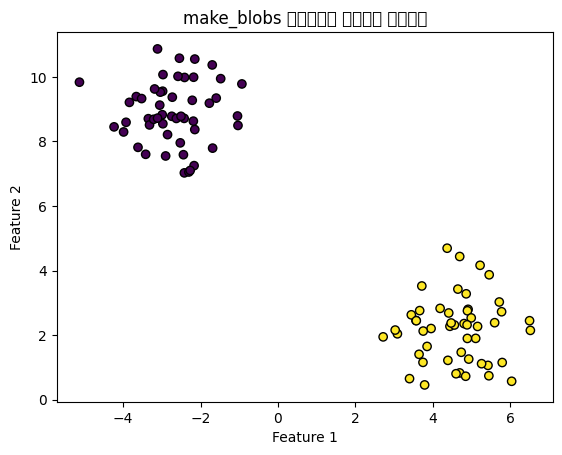

In [2]:
X, y = make_blobs(n_samples=100, centers=2,
                  random_state=42)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, random_state=42)
plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('make_blobs দিয়ে তৈরি ডেটা')
plt.show()

## LogisticRegressionLogisticRegression নামে 'regression' থাকলেও এটি একটি ক্লাসিফিকেশন অ্যালগরিদম!এটি probability আউটপুট দেয় (0 থেকে 1-এর মধ্যে)।

In [3]:
logreg = LogisticRegression()
logreg.fit(X_train, y_train)
y_pred = logreg.predict(X_test)
print('ট্রেন accuracy:', logreg.score(X_train, y_train))
print('টেস্ট accuracy:', logreg.score(X_test, y_test))

ট্রেন accuracy: 1.0
টেস্ট accuracy: 1.0


## Decision Boundary দেখাLogisticRegression-এর decision boundary একটি সরলরেখা। নিচে তা দেখা যাক।

C:\Users\hp\AppData\Local\Temp\ipykernel_7328\4139879550.py:10: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(X_test[:, 0], X_test[:, 1],


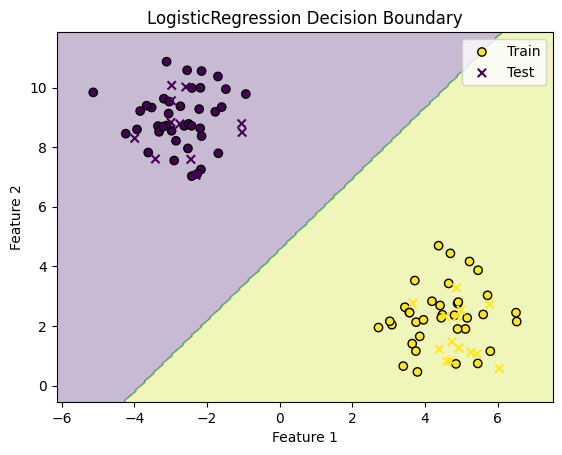

In [4]:
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.05),
                     np.arange(y_min, y_max, 0.05))
Z = logreg.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)
plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X_train[:, 0], X_train[:, 1],
            c=y_train, edgecolors='k', label='Train')
plt.scatter(X_test[:, 0], X_test[:, 1],
            c=y_test, edgecolors='k', marker='x', label='Test')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('LogisticRegression Decision Boundary')
plt.legend()
plt.show()

## LinearSVCLinearSVC (Support Vector Classifier) আরেকটি লিনিয়ার ক্লাসিফায়ার। এটি decision boundary-র দুই পাশে 'margin' (ফাঁকা জায়গা) বাড়ানোর চেষ্টা করে।

C:\Users\hp\AppData\Local\Temp\ipykernel_7328\3559422568.py:8: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(X_test[:, 0], X_test[:, 1],


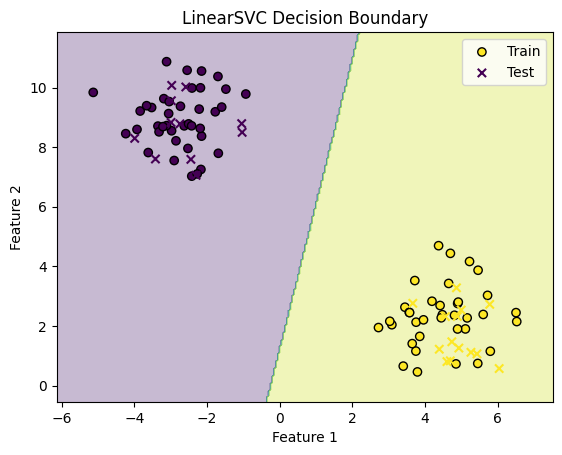

LinearSVC accuracy: 1.0


In [5]:
svc = LinearSVC(random_state=42)
svc.fit(X_train, y_train)
Z = svc.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)
plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X_train[:, 0], X_train[:, 1],
            c=y_train, edgecolors='k', label='Train')
plt.scatter(X_test[:, 0], X_test[:, 1],
            c=y_test, edgecolors='k', marker='x', label='Test')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('LinearSVC Decision Boundary')
plt.legend()
plt.show()
print('LinearSVC accuracy:', svc.score(X_test, y_test))

## C প্যারামিটার (নিয়মিতকরণ)C প্যারামিটার নিয়ন্ত্রণ করে কতটা নিয়মিতকরণ হবে।- **ছোট C:** বেশি নিয়মিতকরণ (সরল মডেল, underfitting)- **বড় C:** কম নিয়মিতকরণ (জটিল মডেল, overfitting)LogisticRegression-এ C-র বিভিন্ন মান试试 করি।

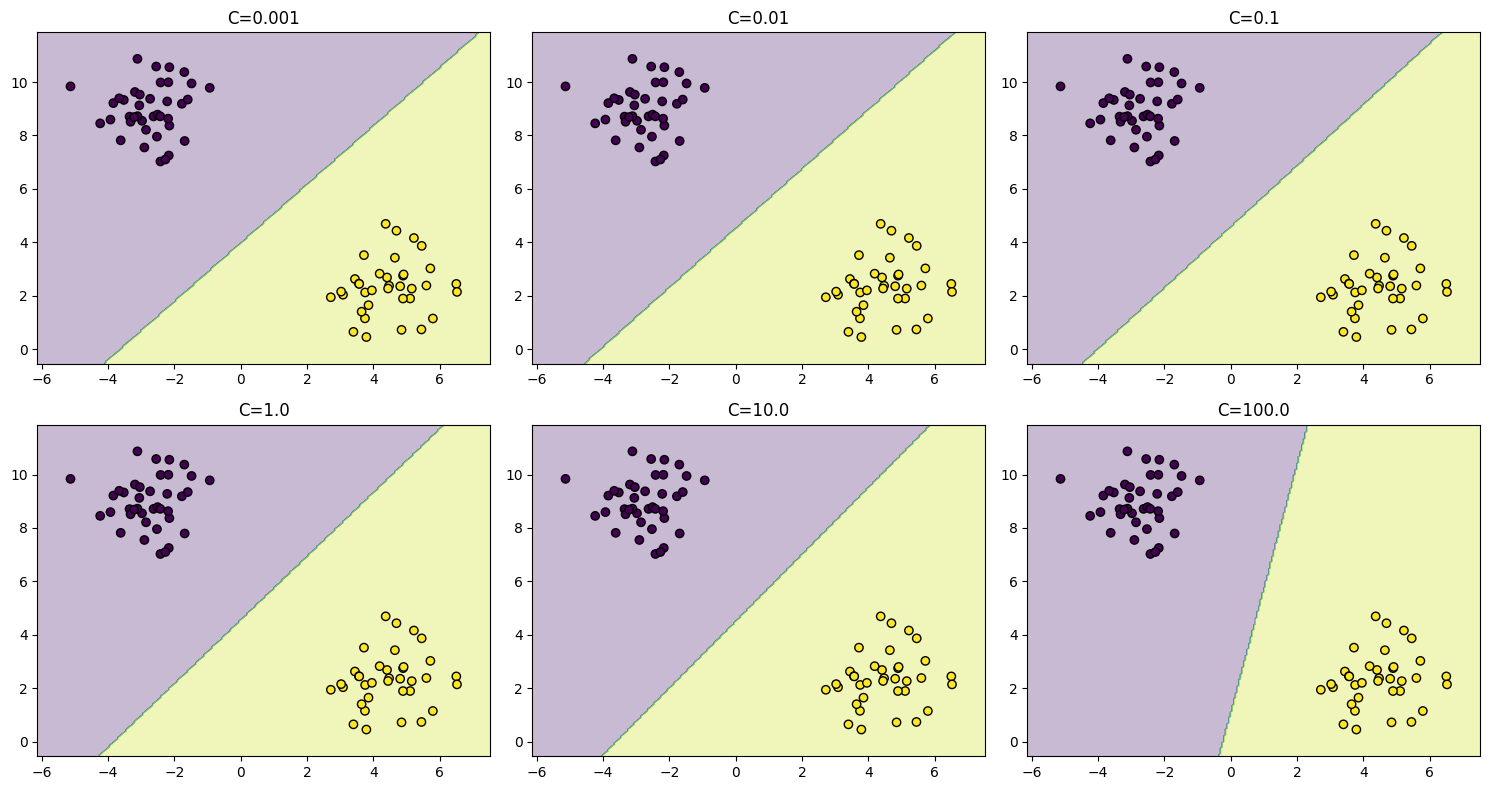

In [6]:
C_values = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.ravel()
for i, C in enumerate(C_values):
    logreg = LogisticRegression(C=C)
    logreg.fit(X_train, y_train)
    Z = logreg.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    axes[i].contourf(xx, yy, Z, alpha=0.3)
    axes[i].scatter(X_train[:, 0], X_train[:, 1],
                    c=y_train, edgecolors='k')
    axes[i].set_title('C={}'.format(C))
plt.tight_layout()
plt.show()

## LogisticRegression vs LinearSVCদুটো মডেলের coefficient তুলনা করি।

In [7]:
X2, y2 = make_classification(n_features=2, n_redundant=0,
                             n_informative=2, random_state=42)
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, random_state=42)
logreg2 = LogisticRegression()
logreg2.fit(X2_train, y2_train)
svc2 = LinearSVC(random_state=42)
svc2.fit(X2_train, y2_train)
print('LogisticRegression coefficients:', logreg2.coef_[0])
print('LinearSVC coefficients:', svc2.coef_[0])
print()
print('LogisticRegression accuracy:', logreg2.score(X2_test, y2_test))
print('LinearSVC accuracy:', svc2.score(X2_test, y2_test))

LogisticRegression coefficients: [ 3.0038577  -0.65615262]
LinearSVC coefficients: [ 1.90085923 -0.53057726]

LogisticRegression accuracy: 0.96
LinearSVC accuracy: 1.0


## সারসংক্ষেপ

| মডেল | বৈশিষ্ট্য |
|-------|----------|
| LogisticRegression | probability দেয়, binary ও multiclass সমর্থন করে |
| LinearSVC | probability দেয় না, বড় ডেটায় দ্রুত |
| C প্যারামিটার | ছোট C = সরল (underfit), বড় C = জটিল (overfit) |